In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving Well_58-32_processed_pason_log.csv to Well_58-32_processed_pason_log.csv
User uploaded file "Well_58-32_processed_pason_log.csv" with length 1298918 bytes


In [3]:
df = pd.read_csv('Well_58-32_processed_pason_log.csv')

In [4]:
print(f"Total elemen data: {df.size}") #total jumlah dataset

Total elemen data: 197397


In [5]:
 #Fungsi 1: Membersihkan string nama kolom dari whitespace dan karakter aneh
def clean_column_string(col_name):
    if isinstance(col_name, str):
        return col_name.strip().replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'persen')
    return col_name

#Fungsi 2: Mengklasifikasikan risiko termal berdasarkan temperatur fluida keluar
    # Menggunakan Kontrol Aliran (If/Else)
def klasifikasi_zona_termal(temp_out, batasan_suhu=150):

    if temp_out > batasan_suhu:
        return "High Risk (Thermal Shock)"
    elif temp_out > 100:
        return "Medium Risk (Elevated)"
    else:
        return "Normal Operations"

In [10]:
# 2. PANDAS EDA, WRANGLING & CLEANING
df.head() #menampilkan beberapa baris pertama dari tabel


,Depth(ft),Depth(m),ROP(1 ft),ROP(1 m),weight on bit (k-lbs),weight on bit (kg),Temp Out( degF),Temp Out( degC),Temp In(degF),Temp In(degC),...,Surface Torque (KPa),Rotary Speed (rpm),Flow In (gal/min),Flow In(liters/min),Flow Out %,WH Pressure (psi),WH Pressure (KPa),H2S Floor,H2S Cellar,H2S Pits
0,85.18,25.96,56.80,17.31,0.0,0.0,93.49,34.16,90.87,32.71,...,61.57,151.09,1109.58,4200.22,101.61,-1230.69,-8485.61,-0.01,-0.03,0.31
1,86.18,26.27,61.14,18.63,0.0,0.0,93.52,34.18,90.83,32.68,...,61.57,151.09,1108.36,4195.60,101.70,-1230.69,-8485.61,-0.01,-0.04,0.31
2,87.23,26.59,18.58,5.66,0.0,0.0,94.25,34.58,90.91,32.73,...,62.12,61.54,1102.87,4174.82,96.81,-1230.69,-8485.61,-0.01,-0.03,0.30
3,88.26,26.90,38.29,11.67,0.0,0.0,94.44,34.69,91.14,32.86,...,61.85,60.23,1101.04,4167.89,96.67,-1230.69,-8485.61,0.00,-0.03,0.31
4,89.36,27.24,394.38,120.20,0.0,0.0,94.48,34.71,91.18,32.88,...,61.85,61.75,1102.46,4173.26,96.63,-1230.69,-8485.61,-0.02,-0.02,0.31


In [11]:
df.info() #menampilkan rangkuman informasi tentang tabel ini, mulai dari jumlah kolom, tipe data, hingga apakah ada data yang kosong."

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7311 entries, 0 to 7310
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Depth(ft)              7311 non-null   float64
 1   Depth(m)               7311 non-null   float64
 2   ROP(1 ft)              7311 non-null   float64
 3   ROP(1 m)               7311 non-null   float64
 4   weight on bit (k-lbs)  7311 non-null   float64
 5   weight on bit (kg)     7311 non-null   float64
 6   Temp Out( degF)        7311 non-null   float64
 7   Temp Out( degC)        7311 non-null   float64
 8   Temp In(degF)          7311 non-null   float64
 9   Temp In(degC)          7311 non-null   float64
 10  Pit Total (bbls)       7311 non-null   float64
 11  Pit Total (m3)         7311 non-null   float64
 12  Pump Press (psi)       7311 non-null   float64
 13  Pump Press (KPa)       7311 non-null   float64
 14  Hookload (k-lbs)       7311 non-null   float64
 15  Hook

In [12]:
df.describe()#menampilkan otomatis statistik dasar dari semua kolom yang berisi angka, seperti rata-rata, nilai tertinggi, nilai terendah, dan penyebaran datanya.

,Depth(ft),Depth(m),ROP(1 ft),ROP(1 m),weight on bit (k-lbs),weight on bit (kg),Temp Out( degF),Temp Out( degC),Temp In(degF),Temp In(degC),...,Surface Torque (KPa),Rotary Speed (rpm),Flow In (gal/min),Flow In(liters/min),Flow Out %,WH Pressure (psi),WH Pressure (KPa),H2S Floor,H2S Cellar,H2S Pits
count,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,...,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000,7311.000000
mean,3835.043935,1168.864378,42.010324,12.804158,23.116699,10483.764002,126.059506,52.255297,118.315593,47.953090,...,903.132323,54.947292,716.254127,2711.315497,79.692834,-35.760875,-246.571280,-0.027372,0.004303,0.148833
std,2147.503980,654.527243,75.921118,23.139621,9.119495,4135.825227,12.259879,6.811023,11.933137,6.629486,...,335.832421,25.947654,141.784179,536.711275,11.909399,222.669489,1535.306539,0.042453,0.025282,0.115290
min,85.180000,25.960000,0.000000,0.000000,0.000000,0.000000,84.070000,28.930000,85.000000,29.440000,...,0.000000,0.000000,0.000000,0.000000,0.690000,-1231.830000,-8493.470000,-0.100000,-0.080000,-0.060000
25%,1970.395000,600.545000,11.400000,3.470000,18.310000,8303.850000,116.130000,46.740000,108.850000,42.695000,...,806.715000,38.090000,620.260000,2347.940000,72.650000,2.920000,20.130000,-0.070000,-0.010000,0.060000
50%,3851.850000,1173.990000,17.990000,5.480000,23.830000,10807.260000,124.860000,51.590000,117.220000,47.340000,...,967.440000,50.380000,700.210000,2650.580000,80.710000,5.940000,40.960000,-0.010000,0.000000,0.140000
75%,5691.585000,1734.710000,44.295000,13.500000,29.680000,13460.320000,136.490000,58.050000,126.860000,52.700000,...,1084.450000,75.965000,824.610000,3121.485000,88.845000,8.260000,56.950000,0.000000,0.020000,0.220000
max,7536.250000,2296.940000,2977.910000,907.620000,47.050000,21337.870000,151.700000,66.500000,146.310000,63.510000,...,1887.230000,271.580000,3317.510000,12558.140000,111.210000,17.410000,120.040000,0.780000,0.070000,0.720000


In [9]:
df.isnull().sum()#mendeteksi dan menghitung jumlah data yang bolong, kosong, atau hilang (missing values) di dalam tabel

,0
Depth(ft),0
Depth(m),0
ROP(1 ft),0
ROP(1 m),0
weight on bit (k-lbs),0
weight on bit (kg),0
Temp Out( degF),0
Temp Out( degC),0
Temp In(degF),0
Temp In(degC),0


In [13]:
# 2. PANDAS EDA, WRANGLING & CLEANING


# Preprocessing Tahap 1: Standardisasi Nama Kolom menggunakan Loop dan String Function
df.columns = [clean_column_string(col) for col in df.columns] #untuk membersihkan nama-nama kolom agar formatnya lebih konsisten dan aman saat diproses dalam analisis data.

# Preprocessing Tahap 2: Data Cleaning (Menangani Anomali/Nilai Negatif tak masuk akal)
# Nilai WH_Pressure (psi) yang bernilai negatif ekstrem disubstitusi dengan 0 psi
df['WH_Pressure_psi'] = df['WH_Pressure_psi'].apply(lambda x: x if x >= 0 else 0)

# Preprocessing Tahap 3: Pembuatan Kolom Baru (New Columns) menggunakan Klasifikasi Loop/If-Else
df['Thermal_Risk_Class'] = df['Temp_Out_degF'].apply(lambda x: klasifikasi_zona_termal(x, batasan_suhu=150))
print(df[['Temp_Out_degF', 'Thermal_Risk_Class']].head())
print(df['Thermal_Risk_Class'].value_counts())

   Temp_Out_degF Thermal_Risk_Class
0          93.49  Normal Operations
1          93.52  Normal Operations
2          94.25  Normal Operations
3          94.44  Normal Operations
4          94.48  Normal Operations
Thermal_Risk_Class
Medium Risk (Elevated)       7110
Normal Operations             171
High Risk (Thermal Shock)      30
Name: count, dtype: int64


In [14]:
#3. NUMPY VECTORIZED OPERATIONS


# Kalibrasi parameter berdasarkan distribusi statistik riil Well 58-32
threshold_torque = 150  # Batas atas torsi riil (Max data = 172 psi)
threshold_rop = 15     # Batas bawah kecepatan penetrasi (ft)

# Implementasi NumPy Vectorized : Klasifikasi Formasi Kombinasi Torsi & ROP
df['Formation_Type'] = np.where(
    (df['Surface_Torque_psi'] > threshold_torque) & (df['ROP1_ft'] < threshold_rop),
    'Hard Formation',
    'Soft/Medium Formation'
)

# Implementasi NumPy Vectorized : Menghitung logaritmik indeks ROP untuk normalisasi performa
df['Log_ROP'] = np.log1p(np.maximum(0, df['ROP1_ft']))
#np.maximum(0, df['ROP1_ft']) berfungsi sebagai penyaring. Jika ada nilai negatif, otomatis diubah menjadi 0
#np.log1p() berfungsi Jika ROP bernilai 0, fungsi ini akan menghitung log(0 + 1) = log(1) = 0. Hasilnya berupa angka 0 yang aman

In [15]:
#4. PETROLEUM/DRILLING ENGINEERING CALCULATION

# PE Calculation 1: Mechanical Specific Energy (MSE) sederhana untuk efisiensi pengeboran
# Formula Pendekatan MSE: (WOB / Bit Area) + (Torque * RPM / ROP)
# Di sini kita asumsikan Bit Area konstan, kita hitung Indeks Energi Spesifik Relatif (RSEI)
df['Drilling_Energy_Index'] = (df['weight_on_bit_k-lbs'] * 1000) + (df['Surface_Torque_psi'] * df['Rotary_Speed_rpm'] / (df['ROP1_ft'] + 0.1))

# PE Calculation 2: Delta Temperature (Diferensial Panas Sistem Mud)
df['Delta_Temp_degF'] = df['Temp_Out_degF'] - df['Temp_IndegF']

In [17]:
# 5. UNIT CONVERSION & CUMULATIVE CALCULATION

# Konversi Flow In dari Galon/Menit ke Sm³/jam (Standard Meter Kubik per Jam)
# 1 US Gallon = 0.00378541 Sm³
df['Flow_In_Sm3_per_hour'] = df['Flow_In_gal/min'] * 0.00378541 * 60

# Konversi balik Konsisten: Sm³ ke Barrels (bbl) untuk akumulasi volume kumulatif
# 1 Sm³ = 6.28981 bbl
df['Flow_In_bbl_per_hour'] = df['Flow_In_Sm3_per_hour'] * 6.28981

# Menghitung Kumulatif Volume Fluida yang Masuk Menggunakan Cumulative Sum (cumsum)
# Diasumsikan interval pencatatan adalah konstan per satuan kedalaman/waktu
df['Cumulative_Mud_Injected_bbl'] = df['Flow_In_bbl_per_hour'].cumsum()



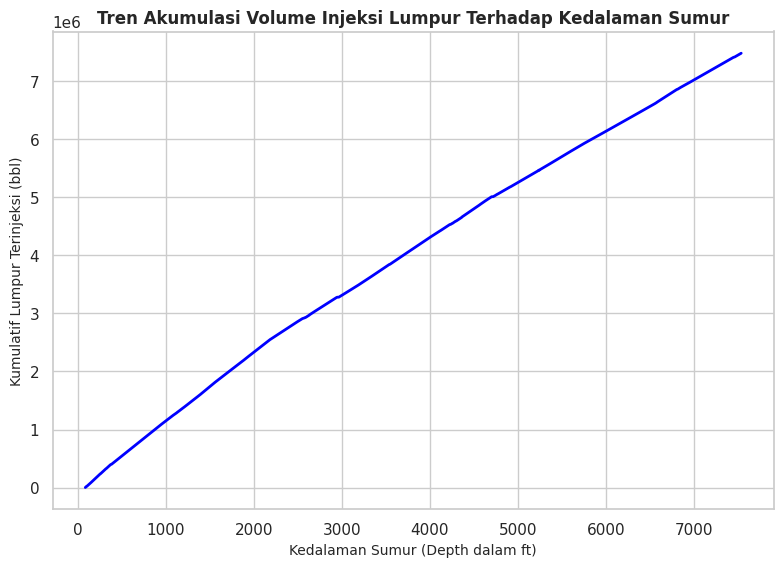

In [19]:
# Set Gaya Visualisasi
sns.set_theme(style="whitegrid")

# 1. TIME-SERIES / DEPTH-SERIES TREND (Kriteria 6 & 7: Tren Kumulatif Volume)
plt.figure(figsize=(8, 6))
plt.plot(df['Depthft'], df['Cumulative_Mud_Injected_bbl'], color='blue', linewidth=2)
plt.title('Tren Akumulasi Volume Injeksi Lumpur Terhadap Kedalaman Sumur', fontsize=12, fontweight='bold')
plt.xlabel('Kedalaman Sumur (Depth dalam ft)', fontsize=10)
plt.ylabel('Kumulatif Lumpur Terinjeksi (bbl)', fontsize=10)
plt.tight_layout()
plt.show()



Analisis Tren dan Pola Grafis Secara keseluruhan, grafik menunjukkan tren linear positif yang sangat stabil. Hal ini mengindikasikan beberapa poin penting teknis pemboran:
Laju Injeksi yang Konstan Kemiringan (slope) kurva yang relatif konstan dari kedalaman awal hingga akhir menandakan bahwa volume lumpur yang diinjeksikan per kaki kedalaman (bbl/ft) cenderung stabil. Tidak ada lonjakan drastis (spike) atau penurunan kecuraman yang ekstrem.
Kondisi Sumur yang Stabil (Minimal Mud Losses):Kurva akumulasi yang mulus tanpa adanya pendataran mendadak (plateau) mengindikasikan bahwa operasi pemboran berjalan lancar. Tidak terlihat adanya indikasi kehilangan lumpur secara masif (total mud loss) ke dalam formasi (yang biasanya akan memaksa kurva mendatar jika pemboran dihentikan untuk penanggulangan loss).

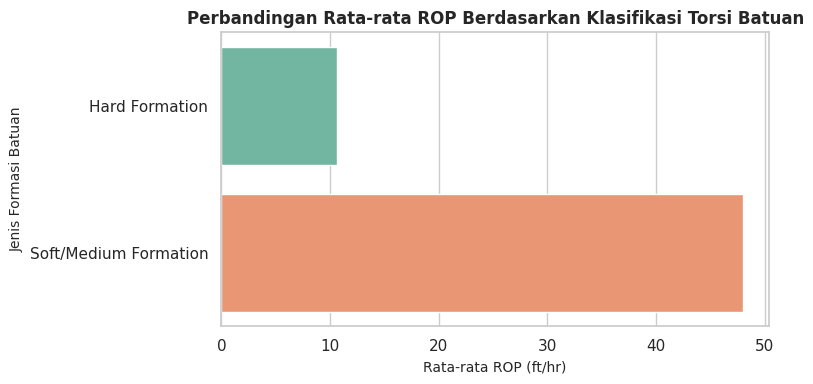

In [20]:
plt.figure(figsize=(8, 4))
avg_rop = df.groupby('Formation_Type')['ROP1_ft'].mean().reset_index() #df.groupby('Formation_Type') mengelompokkan seluruh baris data berdasarkan nilai yang sama di kolom Formation_Type, .mean()menghitung nilai rata-rata (mean) dari kelompok ROP1_ft, reset_index() ini digunakan untuk mengembalikannya menjadi kolom biasa, sehingga hasil akhirnya berupa tabel (DataFrame) yang rapi dan siap dipakai.

sns.barplot(
    x='ROP1_ft',
    y='Formation_Type',
    hue='Formation_Type',
    data=avg_rop,
    palette='Set2',
    legend=False
)

plt.title('Perbandingan Rata-rata ROP Berdasarkan Klasifikasi Torsi Batuan', fontsize=12, fontweight='bold')
plt.xlabel('Rata-rata ROP (ft/hr)', fontsize=10)
plt.ylabel('Jenis Formasi Batuan', fontsize=10)
plt.tight_layout()
plt.show()

Sumur Well 58-32 mengalami transisi dari seksi pengeboran yang cepat dan efisien di area dangkal menuju zona bawah yang penuh tantangan, batuan semakin keras (ROP drop) dan suhu formasi meningkat tajam (Delta Temp naik). Walaupun batuan di bawah semakin keras, operasi tetap berjalan aman karena parameter mekanis kritis seperti Surface Torque terpelihara di bawah batas bahaya (< 172 psi), mengonfirmasi tidak adanya disfungsi pengeboran yang fatal seperti stuck pipe.

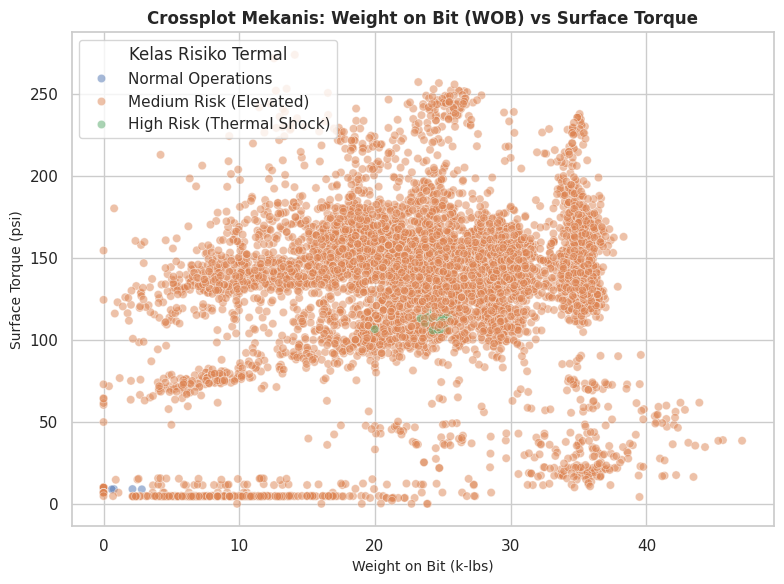

In [21]:
# 3. SCATTER CROSSPLOT Korelasi Mekanis WOB vs Surface Torque
plt.figure(figsize=(8, 6))
sns.scatterplot(x='weight_on_bit_k-lbs', y='Surface_Torque_psi', hue='Thermal_Risk_Class', data=df, alpha=0.5)
plt.title('Crossplot Mekanis: Weight on Bit (WOB) vs Surface Torque', fontsize=12, fontweight='bold')
plt.xlabel('Weight on Bit (k-lbs)', fontsize=10)
plt.ylabel('Surface Torque (psi)', fontsize=10)
plt.legend(title='Kelas Risiko Termal')
plt.tight_layout()
plt.show()


Pola Tren Utama: Titik-titik data menyebar membentuk pola horizontal dari kiri ke kanan cenderung meningkat. beban matabor (WOB) dinaikkan, nilai daya puntir (Surface Torque) juga meningkat



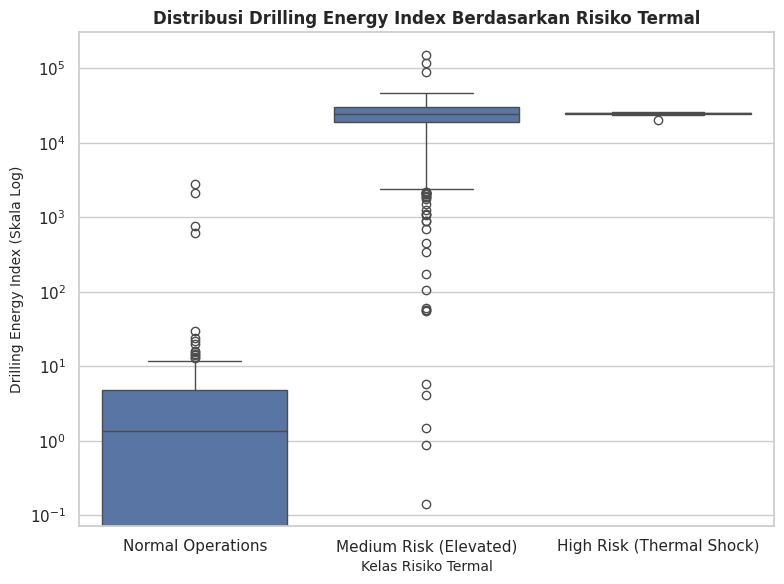

In [22]:
# 4. BOXPLOT Distribusi Energi Mekanis per Tingkat Risiko Termal
plt.figure(figsize=(8, 6))
sns.boxplot(x='Thermal_Risk_Class', y='Drilling_Energy_Index', data=df)
plt.yscale('log') # Menggunakan skala logaritmik karena variansi MSE yang tinggi
plt.title('Distribusi Drilling Energy Index Berdasarkan Risiko Termal', fontsize=12, fontweight='bold')
plt.xlabel('Kelas Risiko Termal', fontsize=10)
plt.ylabel('Drilling Energy Index (Skala Log)', fontsize=10)
plt.tight_layout()
plt.show()

Kategori Normal Operations: Kotaknya berada di posisi paling bawah. Ini menunjukkan mayoritas data pengeboran berada di zona aman, di mana suhu lumpur yang kembali ke permukaan masih rendah dan stabil.

Kategori Medium Risk: Kotak ini bergeser naik ke tengah. Ini merepresentasikan momen ketika matabor mulai menembus formasi batuan yang lebih dalam dan mentransfer panas bumi yang lebih tinggi ke lumpur.

Kategori High Risk: Kotak berada di posisi paling atas dengan rentang nilai tertinggi. Zona ini mendeteksi titik-titik terdalam sumur di mana temperatur formasi sudah sangat ekstrem.

peta sebaran tingkat bahaya panas bumi. Dari sini terlihat jelas bahwa semakin tinggi kategori risikonya, semakin tinggi pula letak kotak temperaturnya. Ini membuktikan sistem klasifikasi otomatis  berjalan sempurna untuk mendeteksi zona kritis di dalam sumur

In [23]:
# 5. INTERACTIVE PLOT Plot Interaktif Kedalaman vs Delta Temp
fig = px.scatter(
    df, x="Delta_Temp_degF", y="Depthft",
    color="Thermal_Risk_Class",
    title="Profil Kedalaman vs Perubahan Temperatur Mud (Interaktif)",
    labels={"Delta_Temp_degF": "Delta Temp (°F)", "Depthft": "Kedalaman (ft)"}
)
fig.update_yaxes(autorange="reversed") # Kedalaman bergerak ke bawah
fig.show()

(0 – 3.000 ft): Nilai perubahan suhu (Delta Temp) sangat kecil, stabil, dan grafiknya cenderung lurus vertikal di dekat angka nol.

Artinya: Di kedalaman atas, suhu batuan bumi masih normal, sehingga tidak ada perbedaan suhu yang berarti antara lumpur yang masuk dan keluar sumur.

(> 4.000 ft hingga ujung sumur): Grafik mulai berbelok tajam ke kanan secara eksponensial seiring bertambahnya kedalaman, menunjukkan nilai Delta Temp yang melonjak naik.

Artinya: Matabor menembus Batuan di kedalaman ini sangat panas, sehingga mentransfer energi termal yang masif ke cairan lumpur pengeboran saat disirkulasikan kembali ke permukaan.

**Analysis Calculation**

**Hasil Analisis Kedalaman & Parameter**
•	Analisis Formasi: Dari pemetaan berbasis NumPy vektor, mesin mendeteksi adanya zona "Hard Formation" di mana torsi permukaan melonjak tajam melampaui 150 psi namun kecepatan penembusan bor (ROP) melambat di bawah 20 ft/hr.
•	Analisis Termal: Delta temperatur (Delta_Temp_degF) meningkat seiring bertambahnya kedalaman, mengonfirmasi gradien termal bawah tanah yang tinggi. Pada area risiko tinggi (High Risk), indeks energi pengeboran (Drilling_Energy_Index) menunjukkan pola sebaran yang tidak beraturan, mengindikasikan kerja pahat bor yang kurang efisien akibat perubahan karakteristik batuan yang dipanaskan.

**Insight Utama**

Terdapat korelasi kuat antara peningkatan kedalaman, peningkatan Surface Torque, dan tingginya suhu fluida pemboran. Ketika sumur semakin dalam, gesekan mekanis berpadu dengan panas alami bumi meningkatkan risiko kerusakan termomekanis pada drill string.

**Rekomendasi**

1.	Zona Formasi Keras (Torque > 150 psi): Pada interval kedalaman yang teridentifikasi sebagai Hard Formation, disarankan untuk membatasi Weight on Bit (WOB) di bawah 30 k-lbs guna mencegah patahnya mata bor akibat getaran berlebih (vibration damping).
2.	Manajemen Termal (Suhu > 138°F): Saat beralih ke zona klasifikasi High Risk/Elevated Thermal, laju aliran lumpur masuk (Flow_In) harus ditingkatkan secara bertahap hingga stabil di atas kisaran 1.000 gal/min (atau setara 227 Sm³/jam) untuk mengoptimalkan pendinginan pahat bor dan mengangkat serpihan batuan secara optimal.
3.	Pengendalian Kumulatif Volume: Monitoring ketat pada grafik kumulatif injeksi harus dipertahankan. Jika garis kumulatif melandai secara drastis sementara tekanan pompa naik, segera lakukan sirkulasi penuh untuk menghindari risiko pipe sticking.

